## <span style="color:#c70d39">**Proyecto Final**</span>

#### <span style="color:#ff5733">**Librerías a utilizar**</span>

In [207]:
#Librerías utilizadas

import os
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import seaborn as sns
import numpy as np
import kaggle
import sqlite3
from sklearn.utils import resample
from scipy.stats import ks_2samp
from sklearn.feature_selection import SelectKBest, f_classif, chi2
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report




### <span style="color:#900c3f">**1. Introducción.**</span>

- **Objetivo del Proyecto**. Poner en práctica los principales conceptos aprendidos sobre la Ciencia de Datos y Machine Learning, tomando un conjunto de datos de la vida real y desarrollar un modelo de aplicación para resolver un problema determinado.

- **Descripción del Problema**. El conjunto de datos representa los accidentes automovilísticos de alcance nacional que cubre 49 estados de los EE. UU. Los datos de accidentes se recopilaron desde febrero de 2016 hasta marzo de 2023, utilizando múltiples API que proporcionan datos de incidentes (o eventos) de tráfico en tiempo real. Estas API transmiten datos de tráfico capturados por varias entidades, incluidos los departamentos de transporte de los EE. UU. y los estados, las agencias de aplicación de la ley, las cámaras de tráfico y los sensores de tráfico dentro de las redes de carreteras. El conjunto de datos contiene actualmente aproximadamente 7,7 millones de registros de accidentes. **Para efectos de este estudio solo se trabajará con la data correspondiente al año 2020**. El modelo a considerar consiste en predecir la severidad en los accidentes. En el DataSet existe una variable multiclase (1,2,3,4) llamada Severity, que describe la gravedad del accidente, esta sería el objetivo o target a predecir, por lo cual, el **modelo sería de clasificación tipo multiclase**.

- **Importancia del Problema**. Este modelo predictivo puede permitir a los servicios de emergencia priorizar y asignar recursos de manera más eficiente. Si se predice que un accidente es de alta severidad, se puede enviar ayuda médica y de rescate más rápidamente. En relación a la gestión del tráfico, las autoridades pueden tomar decisiones informadas para desviar el tráfico y evitar congestiones adicionales. Esto es crucial para minimizar el impacto en la red vial y reducir el riesgo de accidentes secundarios.

    - Severidad 1: Indica el menor impacto en el tráfico, es decir, un retraso corto como resultado del accidente.
    - Severidad 2: Impacto moderado en el tráfico.
    - Severidad 3: Impacto significativo en el tráfico.
    - Severidad 4: Indica un impacto considerable en el tráfico, es decir, un retraso largo como resultado del accidente.


### <span style="color:#900c3f">**2. Extracción, Transformación y Carga de Datos (ETL).**</span>

#### <span style="color:#ff5733">**Método de Recolección.**</span>
Se utilizo el API de Kaggle para descargar la información. Instalación del API en el entorno de trabajo (pip install kaggle), y generación de token en archivo .json que contiene usuario y clave cifrada (mover archvio al directorio raíz .kaggle), para poder importar la libreria (import kaggle) y descargar el Dataset. 

            kaggle.api.dataset_download_files('sobhanmoosavi/us-accidents', path='../data/raw/accidents', unzip=True)         



#### <span style="color:#ff5733">**Fuente de Datos.**</span>El Dataset fue seleccionado de la pagina web de Kaggle https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents

#### <span style="color:#ff5733">**Descripción de los Datos.**</span>
El Dataset (subconjunto 2020) esta compuesto por 1.178.913 registros y 46 características (incluyendo la clase a predecir). Los tipos de variables están distribuidos de la siguiente manera: bool(13), datetime64, float64(12), int64(1), object(18)

- **ID:** Identificador único del accidente.
- **Source:** Fuente de los datos del accidente.
- **Severity:** Gravedad del accidente (generalmente en una escala del 1 al 4).
- **Start_Time:** Fecha y hora de inicio del accidente.
- **End_Time:** Fecha y hora de finalización del accidente.
- **Start_Lat:** Latitud del punto de inicio del accidente.
- **Start_Lng:** Longitud del punto de inicio del accidente.
- **End_Lat:** Latitud del punto de finalización del accidente.
- **End_Lng:** Longitud del punto de finalización del accidente.
- **Distance(mi):** Distancia en millas del accidente.
- **Description:** Descripción textual del accidente.
- **Street:** Calle donde ocurrió el accidente.
- **City:** Ciudad donde ocurrió el accidente.
- **County:** Condado donde ocurrió el accidente.
- **State:** Estado donde ocurrió el accidente.
- **Zipcode:** Código postal del lugar del accidente.
- **Country:** País donde ocurrió el accidente.
- **Timezone:** Zona horaria del lugar del accidente.
- **Airport_Code:** Código del aeropuerto más cercano al accidente.
- **Weather_Timestamp:** Fecha y hora del reporte meteorológico más cercano al accidente.
- **Temperature(F):** Temperatura en grados Fahrenheit en el momento del accidente.
- **Wind_Chill(F):** Sensación térmica en grados Fahrenheit en el momento del accidente.
- **Humidity(%):** Humedad relativa en el momento del accidente.
- **Pressure(in):** Presión atmosférica en pulgadas en el momento del accidente.
- **Visibility(mi):** Visibilidad en millas en el momento del accidente.
- **Wind_Direction:** Dirección del viento en el momento del accidente.
- **Wind_Speed(mph):** Velocidad del viento en millas por hora en el momento del accidente.
- **Precipitation(in):** Precipitación en pulgadas en el momento del accidente.
- **Weather_Condition:** Condiciones meteorológicas en el momento del accidente.
- **Amenity:** Indica si hay una instalación cercana (True/False).
- **Bump:** Indica si hay un bache cercano (True/False).
- **Crossing:** Indica si hay un cruce cercano (True/False).
- **Give_Way:** Indica si hay una señal de ceder el paso cercana (True/False).
- **Junction:** Indica si hay una intersección cercana (True/False).
- **No_Exit:** Indica si hay una salida cercana (True/False).
- **Railway:** Indica si hay una vía de tren cercana (True/False).
- **Roundabout:** Indica si hay una rotonda cercana (True/False).
- **Station:** Indica si hay una estación cercana (True/False).
- **Stop:** Indica si hay una señal de stop cercana (True/False).
- **Traffic_Calming:** Indica si hay una medida de calmado de tráfico cercana (True/False).
- **Traffic_Signal:** Indica si hay un semáforo cercano (True/False).
- **Turning_Loop:** Indica si hay un bucle de giro cercano (True/False).
- **Sunrise_Sunset:** Indica si el accidente ocurrió durante el amanecer o el atardecer.
- **Civil_Twilight:** Indica si el accidente ocurrió durante el crepúsculo civil.
- **Nautical_Twilight:** Indica si el accidente ocurrió durante el crepúsculo náutico.
- **Astronomical_Twilight:** Indica si el accidente ocurrió durante el crepúsculo astronómico.

**No existen registros duplicados.**

**Seguido se muestran la cantidad de valores nulos por características.**

        End_Lat                  470244
        End_Lng                  470244
        Precipitation(in)         62402
        Wind_Chill(F)             40163
        Wind_Direction            35789
        Wind_Speed(mph)           35761
        Humidity(%)               33234
        Temperature(F)            30964
        Visibility(mi)            30356
        Weather_Condition         29974
        Pressure(in)              25915
        Weather_Timestamp         23759
        Airport_Code               3084
        Timezone                   1343
        Street                      437
        Sunrise_Sunset              377
        Astronomical_Twilight       377
        Nautical_Twilight           377
        Civil_Twilight              377
        Zipcode                     358
        City                         50
        Description                   1

#### <span style="color:#ff5733">**Uso API de Kaggle para descargar y descomprimir DataSet objeto del estudio**</span>

In [3]:
# Configurar las credenciales
home = os.path.expanduser('~')
kaggle_dir = os.path.join(home, '.kaggle')
os.makedirs(kaggle_dir, exist_ok=True)


In [4]:
# Descargar el dataset
# kaggle.api.dataset_download_files('sobhanmoosavi/us-accidents', path='../data/raw/accidents', unzip=True)


In [5]:
data_orig=pd.read_csv('../data/raw/accidents/US_Accidents_March23.csv')

In [6]:
data_orig.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     object 
 1   Source                 object 
 2   Severity               int64  
 3   Start_Time             object 
 4   End_Time               object 
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            object 
 11  Street                 object 
 12  City                   object 
 13  County                 object 
 14  State                  object 
 15  Zipcode                object 
 16  Country                object 
 17  Timezone               object 
 18  Airport_Code           object 
 19  Weather_Timestamp      object 
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)       

In [7]:
data_orig['Timezone'].head()

0    US/Eastern
1    US/Eastern
2    US/Eastern
3    US/Eastern
4    US/Eastern
Name: Timezone, dtype: object

#### <span style="color:#ff5733">**Creando subconjunto data_acc (año 2020) del dataframe original, para usarlo en el desarrollo del proyecto**</span>.

In [8]:
# Vamos a convertir las caracteristicas Start_Time, End_Time, Weather_Timestamp  en variables tipo datetime64
data_orig['Start_Time'] = pd.to_datetime(data_orig['Start_Time'], format='mixed', errors='coerce')
data_orig['End_Time'] = pd.to_datetime(data_orig['End_Time'], format='mixed', errors='coerce')
data_orig['Weather_Timestamp'] = pd.to_datetime(data_orig['Weather_Timestamp'], format='mixed', errors='coerce')

# Crear una nueva columna con el año
data_orig['year'] = data_orig['Start_Time'].dt.year

# Crear una nueva columna con la duraccion del accidente en días
data_orig['dur_acc'] = (data_orig['End_Time']- data_orig['Start_Time']).dt.total_seconds()/86400

# Vamos a crear un dataframe (subconjunto) con la data del año 2023. Este será el dataset a usar en este proyecto.
data_acc=data_orig[data_orig.year==2020]

# Reiniciando los indices
data_acc.reset_index(drop=True, inplace=True)

# Lsitando los primeros 5 registros
data_acc.head()


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight,year,dur_acc
0,A-1189513,Source2,2,2020-12-28 05:55:31,2021-01-18 05:00:00,39.376530,-74.478561,NaN,NaN,0.46,...,False,False,False,False,Night,Night,Night,Day,2020,20.961447
1,A-1207989,Source2,3,2020-12-31 22:57:02,2021-01-01 00:29:02,41.932789,-88.038078,NaN,NaN,0.00,...,False,False,False,False,Night,Night,Night,Night,2020,0.063889
2,A-1207990,Source2,3,2020-12-31 22:03:27,2021-01-01 01:43:05,41.623920,-87.680061,NaN,NaN,0.00,...,False,False,False,False,Night,Night,Night,Night,2020,0.152523
3,A-1207991,Source2,3,2020-12-31 22:58:36,2021-01-01 01:02:45,41.794476,-87.631599,NaN,NaN,0.00,...,False,False,True,False,Night,Night,Night,Night,2020,0.086215
4,A-1208128,Source2,2,2020-12-31 23:32:07,2021-01-01 00:51:14,39.771069,-104.847038,NaN,NaN,0.00,...,False,False,True,False,Night,Night,Night,Night,2020,0.054942


In [9]:
data_acc.shape

(1178913, 48)

In [10]:
# Detectar registros duplicados
data_acc.duplicated().sum()

np.int64(0)

In [11]:
# Detectar registros nulos
data_acc.isnull().sum().sort_values(ascending=False)

End_Lat                  470244
End_Lng                  470244
Precipitation(in)         62402
Wind_Chill(F)             40163
Wind_Direction            35789
Wind_Speed(mph)           35761
Humidity(%)               33234
Temperature(F)            30964
Visibility(mi)            30356
Weather_Condition         29974
Pressure(in)              25915
Weather_Timestamp         23759
Airport_Code               3084
Timezone                   1343
Street                      437
Civil_Twilight              377
Astronomical_Twilight       377
Sunrise_Sunset              377
Nautical_Twilight           377
Zipcode                     358
City                         50
Description                   1
State                         0
County                        0
ID                            0
Severity                      0
Distance(mi)                  0
Source                        0
Start_Time                    0
End_Time                      0
Start_Lat                     0
Start_Ln

#### <span style="color:#ff5733">**Eliminando valores nulos**</span>.

Se toma la desicion de eliminar los valores nulos, dado la cantidad de datos que tenemos para el estudio. Quedando al final 649.322 registros.

In [12]:
data_acc.shape

(1178913, 48)

In [13]:
# Generación DataFrame sin valores nulos

df_acc = data_acc.copy()
df_acc.dropna(axis=0, inplace=True)

In [14]:
# Tamaño del nuevo DataSet

df_acc.shape

(649322, 48)

#### <span style="color:#ff5733">**Balanceo de Clases en Variable a Predecir Severity**</span>.

En la siguiente tabla, se observa el desbalanceo de las clases a predecir, lo cual puede ocasionar un sobre ajuste en el modelo final, para evitar este problema se va a disminuir (resample) todas las clases a 24.500 registros, con lo cual se tendría un DataSet final de 98.000 registros para iniciar la siguiente fase del estudio (EDA). 

| Severity |  Count  |
|----------|---------|
|    2     | 555.767 |
|    3     |  43.310 |
|    1     |  25.567 |
|    4     |  24.678 |


In [15]:
df_acc['Severity'].value_counts()

Severity
2    555767
3     43310
1     25567
4     24678
Name: count, dtype: int64

In [16]:
df_acc.isnull().sum()

ID                       0
Source                   0
Severity                 0
Start_Time               0
End_Time                 0
Start_Lat                0
Start_Lng                0
End_Lat                  0
End_Lng                  0
Distance(mi)             0
Description              0
Street                   0
City                     0
County                   0
State                    0
Zipcode                  0
Country                  0
Timezone                 0
Airport_Code             0
Weather_Timestamp        0
Temperature(F)           0
Wind_Chill(F)            0
Humidity(%)              0
Pressure(in)             0
Visibility(mi)           0
Wind_Direction           0
Wind_Speed(mph)          0
Precipitation(in)        0
Weather_Condition        0
Amenity                  0
Bump                     0
Crossing                 0
Give_Way                 0
Junction                 0
No_Exit                  0
Railway                  0
Roundabout               0
S

In [17]:
# Separando las clases
df_sev_1 = df_acc[df_acc.Severity == 1]
df_sev_2 = df_acc[df_acc.Severity == 2]
df_sev_3 = df_acc[df_acc.Severity == 3]
df_sev_4 = df_acc[df_acc.Severity == 4]

# Submuestreando cada clase a 24.500 registros
df_sev_1_d = resample(df_sev_1, replace=False, n_samples=24500, random_state=42) # para reproducibilidad
df_sev_2_d = resample(df_sev_2, replace=False, n_samples=24500, random_state=42) # para reproducibilidad
df_sev_3_d = resample(df_sev_3, replace=False, n_samples=24500, random_state=42) # para reproducibilidad
df_sev_4_d = resample(df_sev_4, replace=False, n_samples=24500, random_state=42) # para reproducibilidad

# Combinar las clases submuestreadas en un nuevo DataFrame
df_acc_bal = pd.concat([df_sev_1_d, df_sev_2_d, df_sev_3_d, df_sev_4_d])

# Mostrar la distribución de las clases después del submuestreo
print(df_acc_bal['Severity'].value_counts())


Severity
1    24500
2    24500
3    24500
4    24500
Name: count, dtype: int64


#### <span style="color:#ff5733">**Prueba de Hipotesis para determinar si la reducción ha afectado significativamente la representatividad de los datos.**</span>.

Para llevar a cabo esta tarea se debe evaluar para cada valor de severidad (1,2,3,4) del conjunto original (649.322 registros) y reducido (24.500 registros), si las características mantienen la misma distribución probabilística en los datos. Las hipotésis a contrastar serían las siguientes:

**Hipótesis Nula (H0)**
- H0: Las distribuciones de la característica en el conjunto de datos original y el conjunto reducido son iguales. No hay diferencia significativa entre las distribuciones. (p_value > 0.05)

**Hipótesis Alternativa (H1)**
- H1: Las distribuciones de la característica en el conjunto de datos original y el conjunto reducido son diferentes. Hay una diferencia significativa entre las distribuciones. (p_value <= 0.05)

En todas las pruebas realizadas con la función **validar_car()**  no existe evidencia para rechachar la Hipotesis Nula, es decir, noy hay diferencias significativas entre las distribuciones de las características de ambos datasets, para cada valor de Severidad (1,2,3,4).  



In [18]:
# Comparar cada característica para Severidad = 1
def validar_car(df_orig,df_red):
    C=0
    for column in df_orig.columns:
        stat, p_value = ks_2samp(df_orig[column], df_red[column])
        if p_value>0.05:
            print(f'La Característica {column} en ambos DataSets son iguales !!! p_value: {p_value:.2f}')
        else:
            print(f'La Característica {column} en ambos DataSets no son iguales XXX p_value: {p_value:.2f}')
            C+=1 
    if C>0:
        print(f'Hay {C} Características que no tienen las mismas distribuciones en ambos DataSets')
    else:
        print("\033[1m\033[4mTODO OK\033[0m")
    return

In [19]:
validar_car(df_sev_1,df_sev_1_d)

La Característica ID en ambos DataSets son iguales !!! p_value: 1.00
La Característica Source en ambos DataSets son iguales !!! p_value: 1.00
La Característica Severity en ambos DataSets son iguales !!! p_value: 1.00
La Característica Start_Time en ambos DataSets son iguales !!! p_value: 1.00
La Característica End_Time en ambos DataSets son iguales !!! p_value: 1.00
La Característica Start_Lat en ambos DataSets son iguales !!! p_value: 1.00
La Característica Start_Lng en ambos DataSets son iguales !!! p_value: 1.00
La Característica End_Lat en ambos DataSets son iguales !!! p_value: 1.00
La Característica End_Lng en ambos DataSets son iguales !!! p_value: 1.00
La Característica Distance(mi) en ambos DataSets son iguales !!! p_value: 1.00
La Característica Description en ambos DataSets son iguales !!! p_value: 1.00
La Característica Street en ambos DataSets son iguales !!! p_value: 1.00
La Característica City en ambos DataSets son iguales !!! p_value: 1.00
La Característica County en am

In [20]:
validar_car(df_sev_2,df_sev_2_d)

La Característica ID en ambos DataSets son iguales !!! p_value: 0.85
La Característica Source en ambos DataSets son iguales !!! p_value: 1.00
La Característica Severity en ambos DataSets son iguales !!! p_value: 1.00
La Característica Start_Time en ambos DataSets son iguales !!! p_value: 0.86
La Característica End_Time en ambos DataSets son iguales !!! p_value: 0.86
La Característica Start_Lat en ambos DataSets son iguales !!! p_value: 0.86
La Característica Start_Lng en ambos DataSets son iguales !!! p_value: 0.96
La Característica End_Lat en ambos DataSets son iguales !!! p_value: 0.78
La Característica End_Lng en ambos DataSets son iguales !!! p_value: 0.96
La Característica Distance(mi) en ambos DataSets son iguales !!! p_value: 0.79
La Característica Description en ambos DataSets son iguales !!! p_value: 0.95
La Característica Street en ambos DataSets son iguales !!! p_value: 0.47
La Característica City en ambos DataSets son iguales !!! p_value: 0.67
La Característica County en am

In [21]:
validar_car(df_sev_3,df_sev_3_d)

La Característica ID en ambos DataSets son iguales !!! p_value: 0.98
La Característica Source en ambos DataSets son iguales !!! p_value: 1.00
La Característica Severity en ambos DataSets son iguales !!! p_value: 1.00
La Característica Start_Time en ambos DataSets son iguales !!! p_value: 0.82
La Característica End_Time en ambos DataSets son iguales !!! p_value: 0.81
La Característica Start_Lat en ambos DataSets son iguales !!! p_value: 0.66
La Característica Start_Lng en ambos DataSets son iguales !!! p_value: 0.82
La Característica End_Lat en ambos DataSets son iguales !!! p_value: 0.67
La Característica End_Lng en ambos DataSets son iguales !!! p_value: 0.83
La Característica Distance(mi) en ambos DataSets son iguales !!! p_value: 0.99
La Característica Description en ambos DataSets son iguales !!! p_value: 0.77
La Característica Street en ambos DataSets son iguales !!! p_value: 0.86
La Característica City en ambos DataSets son iguales !!! p_value: 0.98
La Característica County en am

In [22]:
validar_car(df_sev_4,df_sev_4_d)

La Característica ID en ambos DataSets son iguales !!! p_value: 1.00
La Característica Source en ambos DataSets son iguales !!! p_value: 1.00
La Característica Severity en ambos DataSets son iguales !!! p_value: 1.00
La Característica Start_Time en ambos DataSets son iguales !!! p_value: 1.00
La Característica End_Time en ambos DataSets son iguales !!! p_value: 1.00
La Característica Start_Lat en ambos DataSets son iguales !!! p_value: 1.00
La Característica Start_Lng en ambos DataSets son iguales !!! p_value: 1.00
La Característica End_Lat en ambos DataSets son iguales !!! p_value: 1.00
La Característica End_Lng en ambos DataSets son iguales !!! p_value: 1.00
La Característica Distance(mi) en ambos DataSets son iguales !!! p_value: 1.00
La Característica Description en ambos DataSets son iguales !!! p_value: 1.00
La Característica Street en ambos DataSets son iguales !!! p_value: 1.00
La Característica City en ambos DataSets son iguales !!! p_value: 1.00
La Característica County en am

#### <span style="color:#ff5733">**Creación Base de Datos accidents_usa en Sqlite para almacenar la información del dataframe data_acc**</span>

In [23]:
conn = sqlite3.connect('accidentes_usa.db')
cursor_obj = conn.cursor()

In [24]:
### Carga masiva de los registros en la tabla crime
df_acc_bal.to_sql('acc_usa', conn, if_exists='replace', index=False)

# Confirmar los cambios y cerrar la conexión
conn.commit()
conn.close()

In [25]:
### CONSULTA EN Sqlite de las caracteristicas de las columnas de la tabla crime, perteneciente a la base de datos crime_denver.db

conn = sqlite3.connect('accidentes_usa.db')
cursor_obj = conn.cursor()
statement = '''PRAGMA table_info(acc_usa)'''
cursor_obj.execute(statement)

print("Caracteristicas columnas tabla acc_usa")
output_all = cursor_obj.fetchall()
for row_all in output_all:
  print(row_all)

Caracteristicas columnas tabla acc_usa
(0, 'ID', 'TEXT', 0, None, 0)
(1, 'Source', 'TEXT', 0, None, 0)
(2, 'Severity', 'INTEGER', 0, None, 0)
(3, 'Start_Time', 'TIMESTAMP', 0, None, 0)
(4, 'End_Time', 'TIMESTAMP', 0, None, 0)
(5, 'Start_Lat', 'REAL', 0, None, 0)
(6, 'Start_Lng', 'REAL', 0, None, 0)
(7, 'End_Lat', 'REAL', 0, None, 0)
(8, 'End_Lng', 'REAL', 0, None, 0)
(9, 'Distance(mi)', 'REAL', 0, None, 0)
(10, 'Description', 'TEXT', 0, None, 0)
(11, 'Street', 'TEXT', 0, None, 0)
(12, 'City', 'TEXT', 0, None, 0)
(13, 'County', 'TEXT', 0, None, 0)
(14, 'State', 'TEXT', 0, None, 0)
(15, 'Zipcode', 'TEXT', 0, None, 0)
(16, 'Country', 'TEXT', 0, None, 0)
(17, 'Timezone', 'TEXT', 0, None, 0)
(18, 'Airport_Code', 'TEXT', 0, None, 0)
(19, 'Weather_Timestamp', 'TIMESTAMP', 0, None, 0)
(20, 'Temperature(F)', 'REAL', 0, None, 0)
(21, 'Wind_Chill(F)', 'REAL', 0, None, 0)
(22, 'Humidity(%)', 'REAL', 0, None, 0)
(23, 'Pressure(in)', 'REAL', 0, None, 0)
(24, 'Visibility(mi)', 'REAL', 0, None, 0)
(25

In [26]:
statement = '''SELECT COUNT(*) FROM acc_usa'''
cursor_obj.execute(statement)

print("Total de Registros en la Tabla acc_usa")
output_all = cursor_obj.fetchall()
for row_all in output_all:
  print(row_all)

Total de Registros en la Tabla acc_usa
(98000,)


In [27]:
statement = '''select count(*) from acc_usa where Severity=1'''
cursor_obj.execute(statement)

print("Total registros para Severidad = 1")
output_all = cursor_obj.fetchall()
for row_all in output_all:
  print(row_all)

Total registros para Severidad = 1
(24500,)


In [28]:
statement = '''select * from acc_usa limit(5)'''
cursor_obj.execute(statement)

print("Primeros 5 registros")
output_all = cursor_obj.fetchall()
for row_all in output_all:
  print(row_all)
conn.close

Primeros 5 registros
('A-7178872', 'Source1', 1, '2020-04-15 08:07:46', '2020-04-15 09:12:44', 32.26115, -110.995, 32.26115, -110.995, 0.0, 'At AZ-77/I-10-BL/N Oracle Rd - Accident.', ' W Miracle Mile', 'Tucson', 'Pima', 'AZ', '85705-9319', 'US', 'US/Mountain', 'KDMA', '2020-04-15 07:58:00', 51.0, 51.0, 32.0, 27.24, 10.0, 'ESE', 10.0, 0.0, 'Fair', 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 'Day', 'Day', 'Day', 'Day', 2020, 0.04511574074074074)
('A-7134306', 'Source1', 1, '2020-03-24 15:51:36', '2020-03-24 16:26:34', 27.873690000000003, -80.59146, 27.92451, -80.60212, 3.571, 'At Grant Rd - Accident. Hard shoulder blocked.', 'Micco Rd', 'Sebastian', 'Brevard', 'FL', '32976', 'US', 'US/Eastern', 'KVRB', '2020-03-24 15:53:00', 83.0, 83.0, 56.0, 30.02, 10.0, 'SE', 18.0, 0.0, 'Mostly Cloudy', 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 'Day', 'Day', 'Day', 'Day', 2020, 0.02428240740740741)
('A-7001615', 'Source1', 1, '2020-06-04 13:31:33', '2020-06-04 14:16:33', 32.206959999999995, -110.92228, 32.206

<function Connection.close()>

### <span style="color:#900c3f">**2. Análisis Exploratorio de Datos (EDA).**</span>

#### <span style="color:#ff5733">**Estadísticas Descriptivas.**</span>

- Previamente se había determinado que no existían registros duplicados.
- Los registros nulos fueron eliminados.
- Existen muchas variables realacionadas con el lugar donde ocurrieron los accidentes, de hecho, existen coordenadas para el inicio y el fin del mismo, en los siguientes análisis se tomarán las referidas al inicio, es decir, **Start_Lat y Start_Lng**. Se descartarán de igual manera, otras características asociadas a la ubicación del siniestro: 
    - Street.
    - City.
    - County.
    - State.
    - Zipcode.
    - Country. 
- Se tienen otras características que no están vinculadas a simple vista con la Clase Objetivo Severity, que serán eliminadas del subconjunto final, las mismas son:
    - ID.
    - Source.
    - Star_Time y End_Time (reeemplazadas por su diferencia, la cual llamaremos, dururación del accidente, **dur_acc**).
    - Descripción.
    - Year.
- Dado que nos quedan aún 34 Características incluyendo la clase a predecir (Severity), vamos a apoyarnos en la librería SelectKBest de Sklearn para escoger las mejores características para desarrollar el modelo.



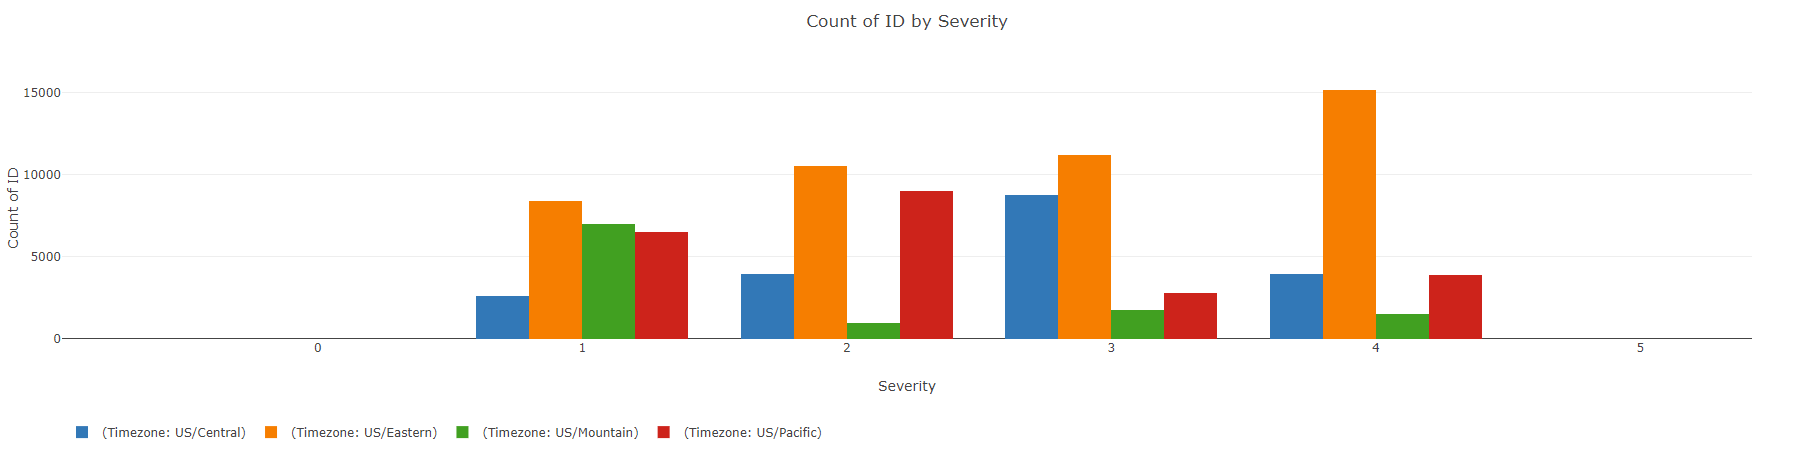

In [29]:
df_acc_bal.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98000 entries, 1072586 to 588719
Data columns (total 48 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   ID                     98000 non-null  object        
 1   Source                 98000 non-null  object        
 2   Severity               98000 non-null  int64         
 3   Start_Time             98000 non-null  datetime64[ns]
 4   End_Time               98000 non-null  datetime64[ns]
 5   Start_Lat              98000 non-null  float64       
 6   Start_Lng              98000 non-null  float64       
 7   End_Lat                98000 non-null  float64       
 8   End_Lng                98000 non-null  float64       
 9   Distance(mi)           98000 non-null  float64       
 10  Description            98000 non-null  object        
 11  Street                 98000 non-null  object        
 12  City                   98000 non-null  object        
 13 

#### <span style="color:#ff5733">**Ubicación de los datos por Severidad en mapa USA.**</span>

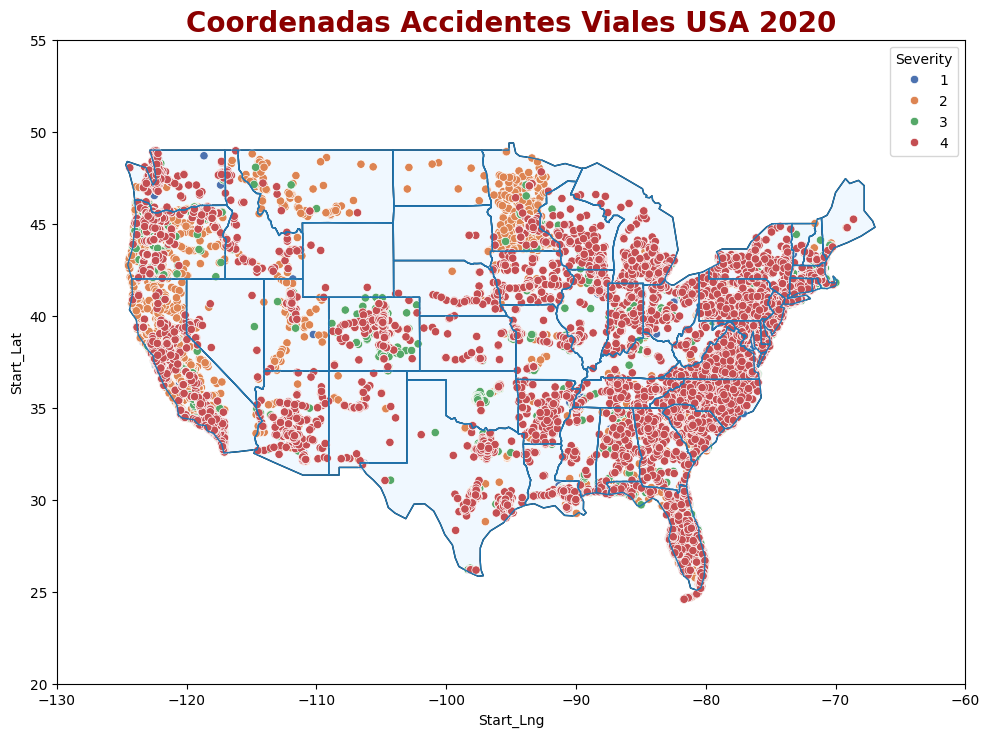

In [96]:
# Ruta al archivo shapefile extraído
shapefile_path = '../data/raw/mapa_usa/ne_110m_admin_1_states_provinces.shp'

# Cargar el shapefile de los Estados Unidos
states = gpd.read_file(shapefile_path)
usa = states[states['admin'] == "United States of America"]

# Crear una figura y un eje
fig, ax = plt.subplots(figsize=(10, 10))

# Definiendo límites del mapa para excluir Alaska y Hawaii 
ax.set_xlim(-130, -60)
ax.set_ylim(20, 55)

# Plotear el mapa de USA con los estados
usa.boundary.plot(ax=ax, linewidth=1)
usa.plot(ax=ax, color='aliceblue', edgecolor='black')

# Determinar el número de categorías únicas en 'Severity'
num_cat = df_acc_bal['Severity'].nunique()

# Seleccionar una paleta con el número adecuado de colores
custom_palette = sns.color_palette("deep", num_cat)

# Crear el scatter plot
plt.title('Coordenadas Accidentes Viales USA 2020',fontdict={'fontsize': 20, 'fontweight': 'bold', 'color': 'darkred'})

sns.scatterplot(x='Start_Lng', y='Start_Lat', hue='Severity', data=df_acc_bal, palette=custom_palette)
plt.tight_layout()
plt.show()

In [103]:
df_acc_bal.shape

(98000, 48)

In [129]:
car_parciales=['Severity','Start_Lat',
       'Start_Lng','Distance(mi)','Timezone', 'Airport_Code', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight','dur_acc']

In [130]:
print(len(car_parciales))

33


#### <span style="color:#ff5733">**SelectKbest para seleccionar mejores características del modelo.**</span>

- La idea de aplicar este técnica es seleccionar, por lo menos, 14 características e iniciar las visualizaciones de la variable objetivo versus cada característica.

- Debemos determinar las estadisticas descriptivas, valores atípicos y otras datos de interés de cada variable.

- Finalmente, la tabla de correlación no datá una guia final para seleccionar las características finales del estudio.

In [152]:
df_par=df_acc_bal[car_parciales]

# Separar las características (X) y la variable objetivo (y)
X = df_par.drop('Severity', axis=1)
y = pd.DataFrame(df_par['Severity'])

In [153]:
y.value_counts()

Severity
1           24500
2           24500
3           24500
4           24500
Name: count, dtype: int64

In [154]:
X.head()

,Start_Lat,Start_Lng,Distance(mi),Timezone,Airport_Code,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),...,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight,dur_acc
1072586,32.26115,-110.99500,0.000,US/Mountain,KDMA,51.0,51.0,32.0,27.24,10.0,...,False,False,False,True,False,Day,Day,Day,Day,0.045116
1028032,27.87369,-80.59146,3.571,US/Eastern,KVRB,83.0,83.0,56.0,30.02,10.0,...,False,False,False,False,False,Day,Day,Day,Day,0.024282
895381,32.20696,-110.92228,0.000,US/Mountain,KTUS,101.0,101.0,14.0,27.05,10.0,...,False,True,False,True,False,Day,Day,Day,Day,0.031250
983525,33.39227,-112.09920,0.000,US/Mountain,KPHX,97.0,97.0,9.0,28.59,10.0,...,False,False,False,True,False,Night,Night,Night,Night,0.031250
1073963,35.54284,-82.60367,0.000,US/Eastern,KAVL,59.0,59.0,28.0,27.95,10.0,...,False,False,False,False,False,Day,Day,Day,Day,0.025000


In [159]:
# Convertir variables categóricas a numéricas usando OrdinalEncoder

categorical_cols = X.select_dtypes(include=['object']).columns
encoder = OrdinalEncoder()
X[categorical_cols] = encoder.fit_transform(X[categorical_cols])
X.head()



,Start_Lat,Start_Lng,Distance(mi),Timezone,Airport_Code,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),...,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight,dur_acc
1072586,32.26115,-110.99500,0.000,2.0,355.0,51.0,51.0,32.0,27.24,10.0,...,False,False,False,True,False,0.0,0.0,0.0,0.0,0.045116
1028032,27.87369,-80.59146,3.571,1.0,1404.0,83.0,83.0,56.0,30.02,10.0,...,False,False,False,False,False,0.0,0.0,0.0,0.0,0.024282
895381,32.20696,-110.92228,0.000,2.0,1348.0,101.0,101.0,14.0,27.05,10.0,...,False,True,False,True,False,0.0,0.0,0.0,0.0,0.031250
983525,33.39227,-112.09920,0.000,2.0,1078.0,97.0,97.0,9.0,28.59,10.0,...,False,False,False,True,False,1.0,1.0,1.0,1.0,0.031250
1073963,35.54284,-82.60367,0.000,1.0,134.0,59.0,59.0,28.0,27.95,10.0,...,False,False,False,False,False,0.0,0.0,0.0,0.0,0.025000


In [161]:
X.shape

(98000, 32)

#### <span style="color:#ff5733">**DataSet con mejores Características.**</span>

In [166]:
# Normalizar los datos para que estén en el rango [0, 1], los valores para SelectKbest no pueden ser negativos
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Seleccionar las mejores 14 características
selector = SelectKBest(score_func=chi2, k=14)
X_new = selector.fit_transform(X_scaled, y)

# Obtener las características seleccionadas
selected_features = X.columns[selector.get_support()]
print(selected_features)


Index(['Start_Lat', 'Start_Lng', 'Timezone', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Wind_Direction', 'Crossing', 'Junction',
       'Traffic_Signal', 'Sunrise_Sunset', 'Civil_Twilight',
       'Nautical_Twilight', 'Astronomical_Twilight'],
      dtype='object')


In [168]:
car_best=['Start_Lat', 'Start_Lng', 'Timezone', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Wind_Direction', 'Crossing', 'Junction',
       'Traffic_Signal', 'Sunrise_Sunset', 'Civil_Twilight',
       'Nautical_Twilight', 'Astronomical_Twilight']

In [170]:
X_best=X[car_best]
data_sel=pd.concat([X_best,y],axis=1)

In [200]:
data_sel.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98000 entries, 1072586 to 588719
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Start_Lat              98000 non-null  float64
 1   Start_Lng              98000 non-null  float64
 2   Timezone               98000 non-null  float64
 3   Temperature(F)         98000 non-null  float64
 4   Wind_Chill(F)          98000 non-null  float64
 5   Humidity(%)            98000 non-null  float64
 6   Wind_Direction         98000 non-null  float64
 7   Crossing               98000 non-null  bool   
 8   Junction               98000 non-null  bool   
 9   Traffic_Signal         98000 non-null  bool   
 10  Sunrise_Sunset         98000 non-null  float64
 11  Civil_Twilight         98000 non-null  float64
 12  Nautical_Twilight      98000 non-null  float64
 13  Astronomical_Twilight  98000 non-null  float64
 14  Severity               98000 non-null  int64  
 15  

In [202]:
# Convirtiendo Variables tipo bool en numerica y reasignando para 1 para True y 0 para False
data_sel['Crossing_n'], _ = pd.factorize(data_sel['Crossing'])
data_sel['Crossing_n'] = data_sel['Crossing_n'].map({0: 1, 1: 0})

data_sel['Junction_n'], _ = pd.factorize(data_sel['Junction'])

data_sel['Traffic_Signal_n'], _ = pd.factorize(data_sel['Traffic_Signal'])
data_sel['Traffic_Signal_n'] = data_sel['Traffic_Signal_n'].map({0: 1, 1: 0})

borrar=['Crossing','Junction','Traffic_Signal']
data_sel.drop(borrar, axis=1, inplace=True)


In [203]:
data_sel.head()

,Start_Lat,Start_Lng,Timezone,Temperature(F),Wind_Chill(F),Humidity(%),Wind_Direction,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight,Severity,Crossing_n,Junction_n,Traffic_Signal_n
1072586,32.26115,-110.99500,2.0,51.0,51.0,32.0,3.0,0.0,0.0,0.0,0.0,1,1,0,1
1028032,27.87369,-80.59146,1.0,83.0,83.0,56.0,10.0,0.0,0.0,0.0,0.0,1,0,0,0
895381,32.20696,-110.92228,2.0,101.0,101.0,14.0,4.0,0.0,0.0,0.0,0.0,1,1,0,1
983525,33.39227,-112.09920,2.0,97.0,97.0,9.0,15.0,1.0,1.0,1.0,1.0,1,1,0,1
1073963,35.54284,-82.60367,1.0,59.0,59.0,28.0,4.0,0.0,0.0,0.0,0.0,1,0,0,0


#### <span style="color:#ff5733">**Graficos Variables Numericas.**</span>

En esta parte del proyecto vamos a utilizar la librería de Python D-tale, con el objeto de agilizar las estadísticas descritptivas de las variables, su distribución y su relación con el objetivo a predecir (Severity).

La librería se configuró en un entorno virtual distinto y se ejecutó en el archivo Eda_Dtale.ipynb, adjunto en el directorio ../src

In [237]:
data_sel.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98000 entries, 1072586 to 588719
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Start_Lat              98000 non-null  float64
 1   Start_Lng              98000 non-null  float64
 2   Timezone               98000 non-null  float64
 3   Temperature(F)         98000 non-null  float64
 4   Wind_Chill(F)          98000 non-null  float64
 5   Humidity(%)            98000 non-null  float64
 6   Wind_Direction         98000 non-null  float64
 7   Sunrise_Sunset         98000 non-null  float64
 8   Civil_Twilight         98000 non-null  float64
 9   Nautical_Twilight      98000 non-null  float64
 10  Astronomical_Twilight  98000 non-null  float64
 11  Severity               98000 non-null  int64  
 12  Crossing_n             98000 non-null  int64  
 13  Junction_n             98000 non-null  int64  
 14  Traffic_Signal_n       98000 non-null  int64  
dtype

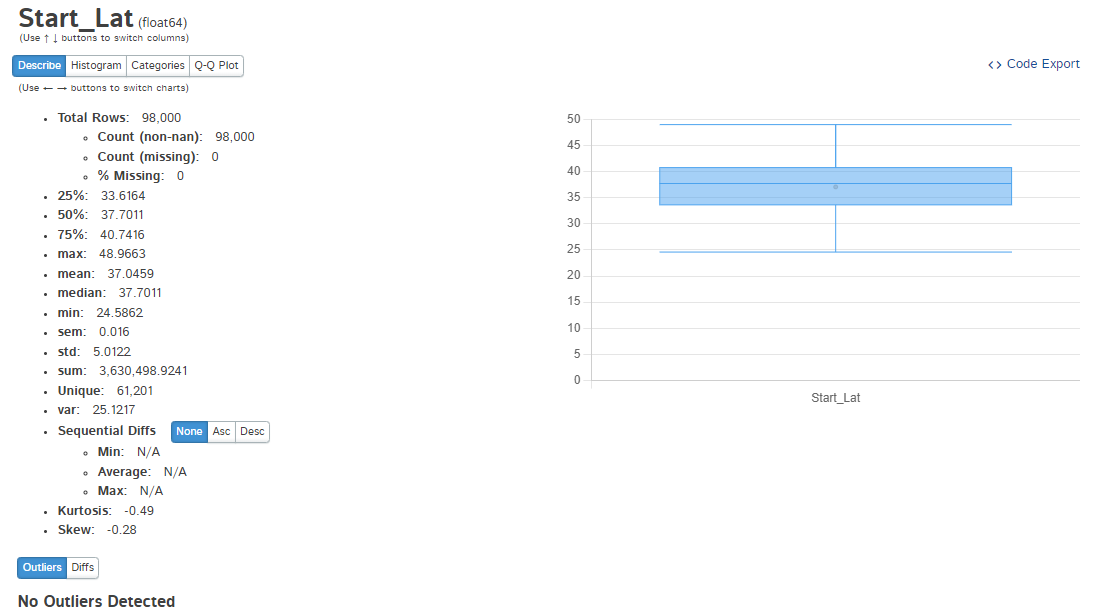

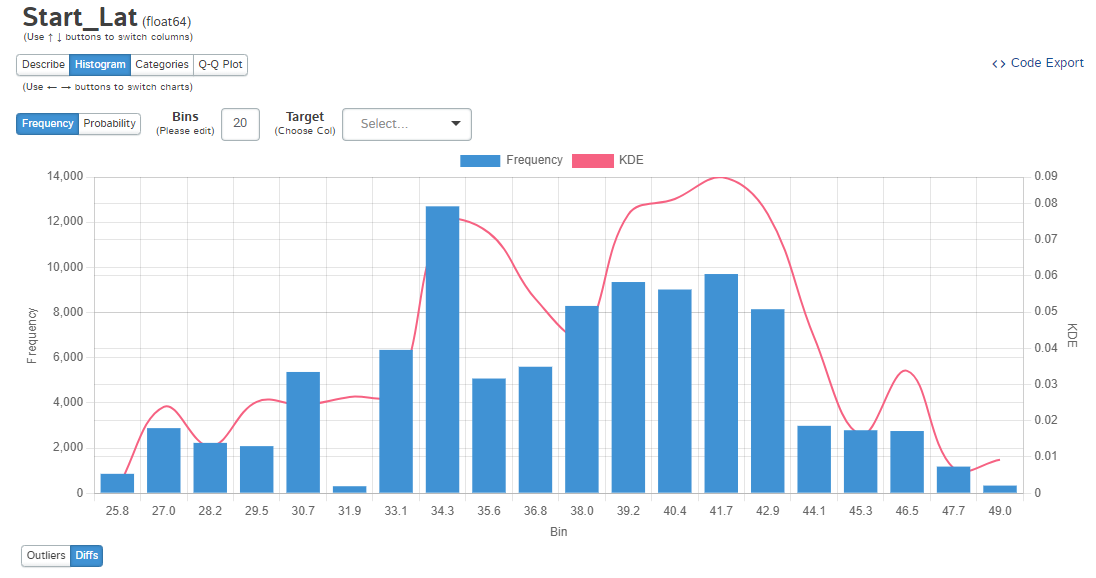

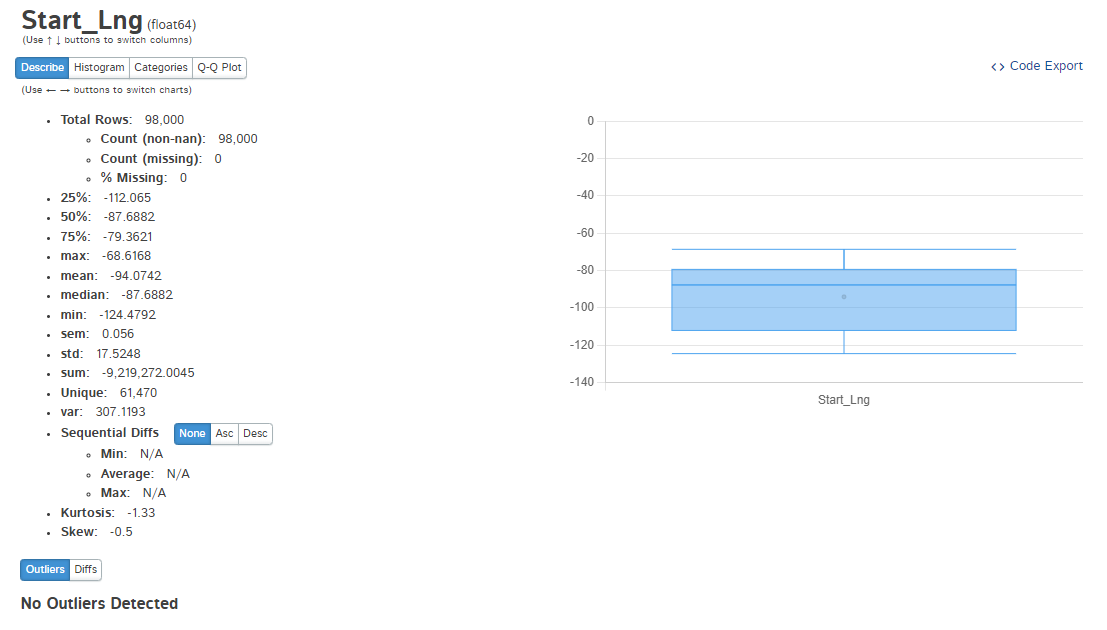

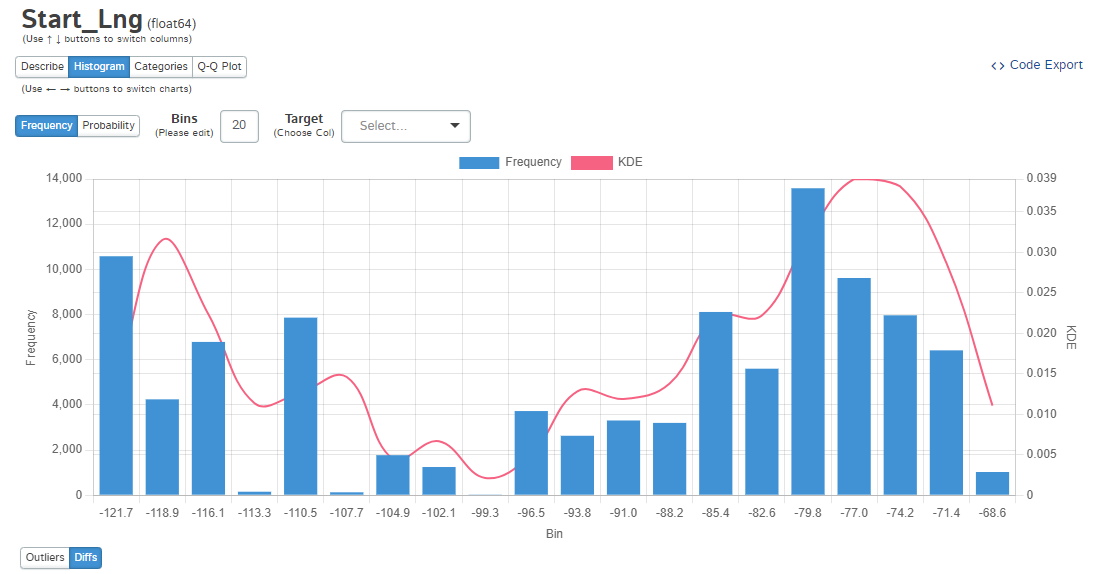

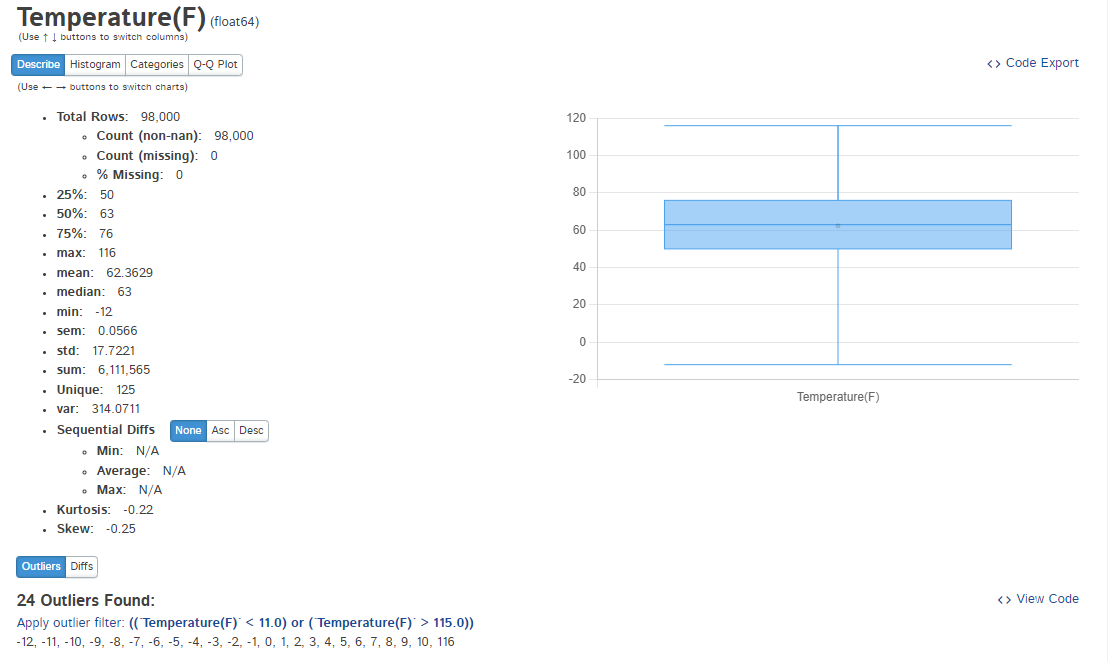

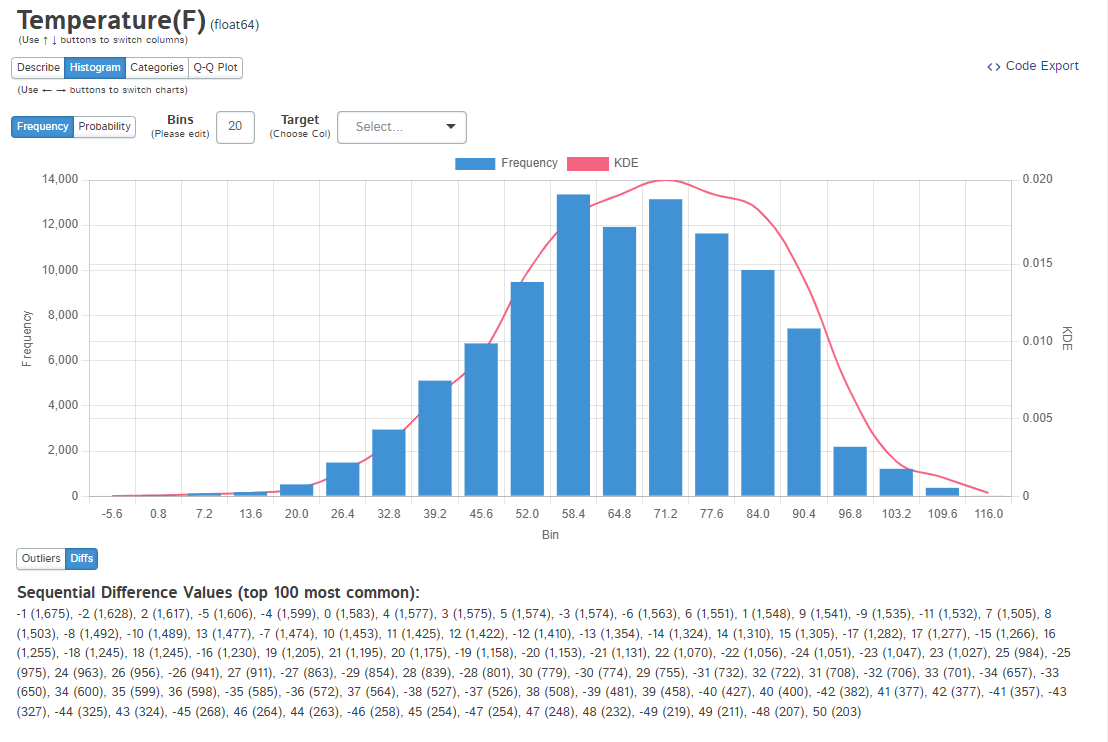

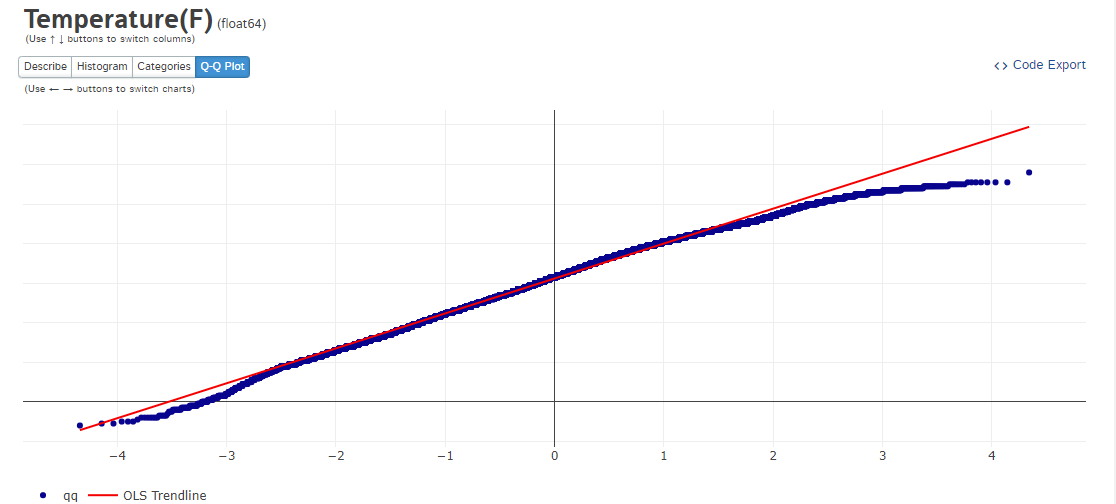

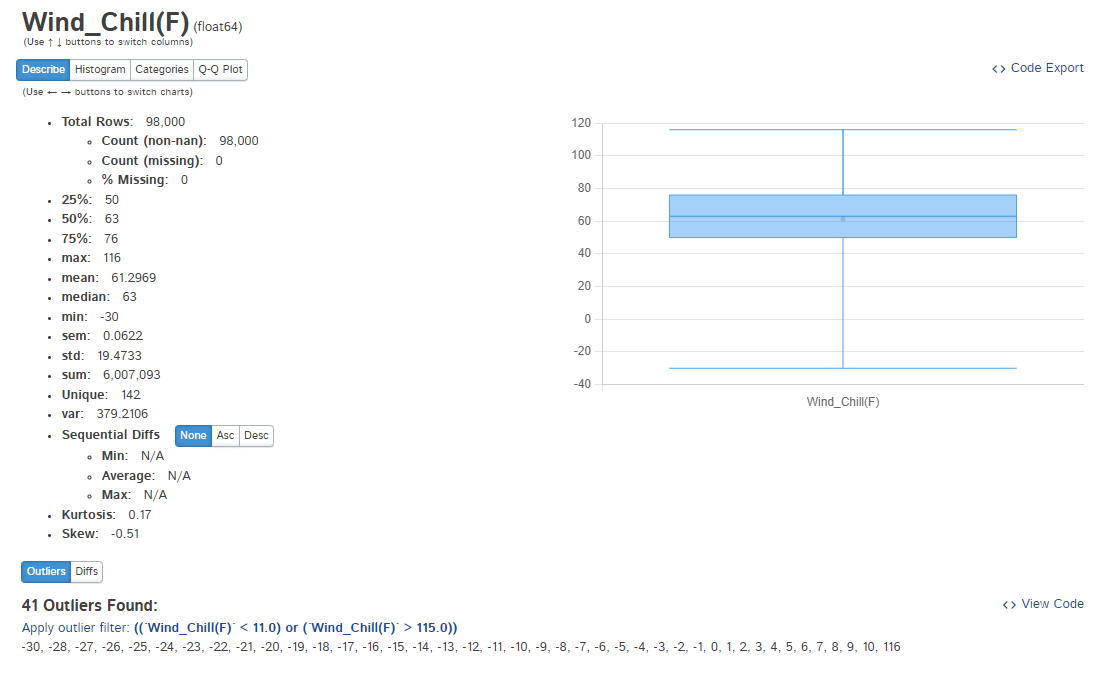

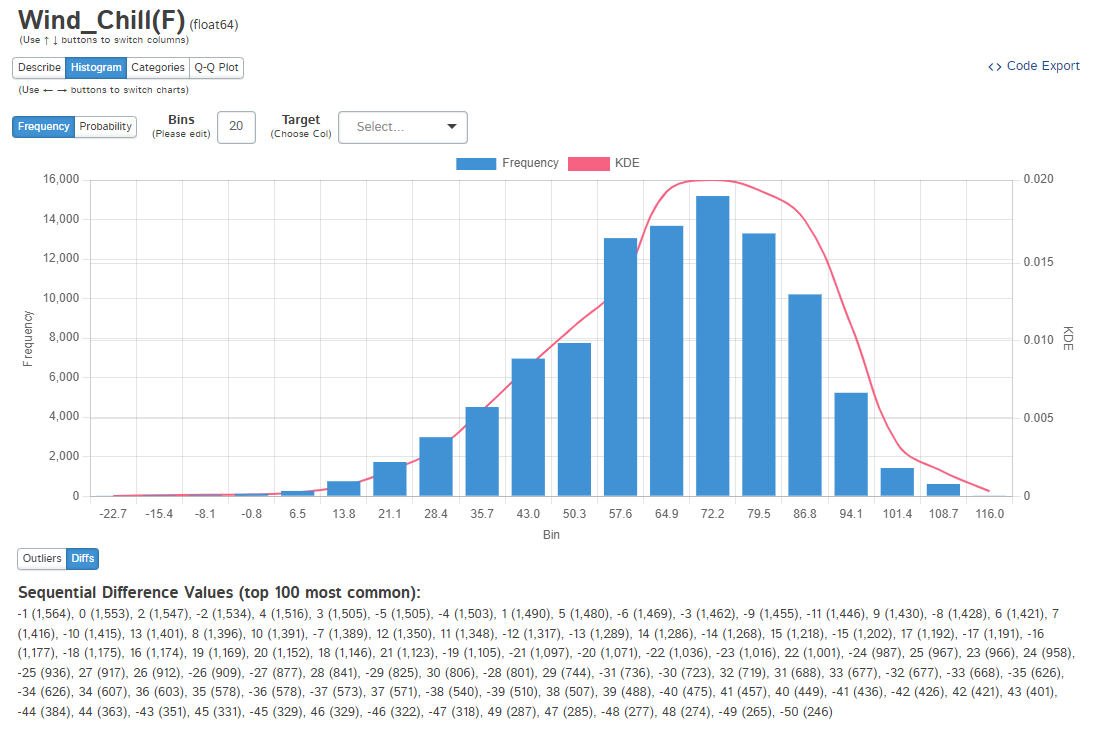

In [205]:
data_sel.columns

Index(['Start_Lat', 'Start_Lng', 'Timezone', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Wind_Direction', 'Sunrise_Sunset', 'Civil_Twilight',
       'Nautical_Twilight', 'Astronomical_Twilight', 'Severity', 'Crossing_n',
       'Junction_n', 'Traffic_Signal_n'],
      dtype='object')

#### Posibles Variables del Modelo

In [221]:
X_f=['Start_Lat', 'Start_Lng', 'Temperature(F)', 
       'Humidity(%)', 'Sunrise_Sunset', 'Crossing_n',
       'Traffic_Signal_n']
X_mod=data_sel[X_f]
y_f=data_sel['Severity']

In [223]:
X_mod.shape

(98000, 7)

In [222]:
y_f

1072586    1
1028032    1
895381     1
983525     1
1073963    1
          ..
908666     4
1015705    4
624051     4
971738     4
588719     4
Name: Severity, Length: 98000, dtype: int64

In [224]:
# Supongamos que ya tienes tus DataFrames X_mod y y cargados
# Dividir los datos en conjuntos de entrenamiento y prueba

X_train, X_test, y_train, y_test = train_test_split(X_mod, y_f, test_size=0.2, random_state=42)

# Crear el modelo
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Entrenar el modelo
rf_model.fit(X_train, y_train)

# Hacer predicciones
y_pred = rf_model.predict(X_test)

# Evaluar el modelo
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           1       0.77      0.83      0.80      4917
           2       0.69      0.62      0.65      4971
           3       0.70      0.70      0.70      4910
           4       0.69      0.69      0.69      4802

    accuracy                           0.71     19600
   macro avg       0.71      0.71      0.71     19600
weighted avg       0.71      0.71      0.71     19600

